In [ ]:
# Import libraries\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import train_test_split, cross_val_score\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.ensemble import RandomForestClassifier\nfrom xgboost import XGBClassifier\nfrom sklearn.metrics import classification_report, confusion_matrix, accuracy_score\nimport warnings\nwarnings.filterwarnings('ignore')\n\nplt.style.use('seaborn-v0_8-darkgrid')\n%matplotlib inline\nprint('✅ Libraries imported!')

In [ ]:
# Load and prepare data\ndf = pd.read_csv('../data/raw/sample_user_data.csv')\nfeatures = ['sleep_hours', 'workload_hours', 'stress_level', 'screen_time', \n            'physical_activity', 'social_interaction', 'meal_quality', 'productivity_score']\n\nle = LabelEncoder()\ndf['burnout_risk_encoded'] = le.fit_transform(df['burnout_risk'])\n\nX = df[features]\ny = df['burnout_risk_encoded']\n\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)\n\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\nprint(f'Training set size: {len(X_train)}')\nprint(f'Test set size: {len(X_test)}')\nprint(f'Classes: {list(le.classes_)}')

In [ ]:
# Define and train models\nmodels = {\n    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),\n    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),\n    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')\n}\n\nresults = {}\n\nfor name, model in models.items():\n    print(f'\\nTraining {name}...')\n    model.fit(X_train_scaled, y_train)\n    y_pred = model.predict(X_test_scaled)\n    accuracy = accuracy_score(y_test, y_pred)\n    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)\n    results[name] = {\n        'accuracy': accuracy,\n        'cv_mean': cv_scores.mean(),\n        'cv_std': cv_scores.std(),\n        'model': model,\n        'predictions': y_pred\n    }\n    print(f'Accuracy: {accuracy:.4f}')\n    print(f'CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')\n    print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
# Compare model performance\ncomparison_df = pd.DataFrame({\n    'Model': list(results.keys()),\n    'Test Accuracy': [results[m]['accuracy'] for m in results],\n    'CV Mean': [results[m]['cv_mean'] for m in results],\n    'CV Std': [results[m]['cv_std'] for m in results]\n})\ncomparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)\ncomparison_df

In [ ]:
# Visualize model comparison\nfig, ax = plt.subplots(figsize=(10, 6))\n\nx = range(len(comparison_df))\nwidth = 0.35\n\nbars1 = ax.bar([i - width/2 for i in x], comparison_df['Test Accuracy'], width, label='Test Accuracy', color='#4f46e5')\nbars2 = ax.bar([i + width/2 for i in x], comparison_df['CV Mean'], width, label='CV Mean', color='#10b981')\n\nax.set_xlabel('Model')\nax.set_ylabel('Score')\nax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')\nax.set_xticks(x)\nax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')\nax.legend()\nax.set_ylim(0, 1)\n\nfor bars in [bars1, bars2]:\n    for bar in bars:\n        height = bar.get_height()\n        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),\n                   xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)\n\nplt.tight_layout()\nplt.show()

In [ ]:
#Feature importance\nfig, axes = plt.subplots(1, 2, figsize=(14, 6))\n\n# Random Forest\nrf_model = results['Random Forest']['model']\nrf_importance = pd.DataFrame({\n    'feature': features,\n    'importance': rf_model.feature_importances_\n}).sort_values('importance', ascending=True)\n\naxes[0].barh(rf_importance['feature'], rf_importance['importance'], color='#4f46e5')\naxes[0].set_xlabel('Importance')\naxes[0].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')\n\n# XGBoost\nxgb_model = results['XGBoost']['model']\nxgb_importance = pd.DataFrame({\n    'feature': features,\n    'importance': xgb_model.feature_importances_\n}).sort_values('importance', ascending=True)\n\naxes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='#10b981')\naxes[1].set_xlabel('Importance')\naxes[1].set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')\n\nplt.tight_layout()\nplt.show()

In [ ]:
# Confusion matrices\nfig, axes = plt.subplots(1, 3, figsize=(15, 4))\n\nfor idx, (name, result) in enumerate(results.items()):\n    cm = confusion_matrix(y_test, result['predictions'])\n    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],\n                xticklabels=le.classes_, yticklabels=le.classes_)\n    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')\n    axes[idx].set_xlabel('Predicted')\n    axes[idx].set_ylabel('Actual')\n\nplt.tight_layout()\nplt.show()

In [ ]:
# Summary\nprint('='*60)\nprint('MODEL TRAINING SUMMARY')\nprint('='*60)\nprint(f"Best performing model: {comparison_df.iloc[0]['Model']}")\nprint(f"Test accuracy: {comparison_df.iloc[0]['Test Accuracy']:.4f}")\nprint(f"Cross-validation score: {comparison_df.iloc[0]['CV Mean']:.4f}")\nprint(f"\nTop 3 most important features (XGBoost):")\nfor i, row in xgb_importance.tail(3).iterrows():\n    print(f"  {row['feature']}: {row['importance']:.4f}")

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# Load and prepare data
df = pd.read_csv('../data/raw/sample_user_data.csv')
features = ['sleep_hours', 'workload_hours', 'stress_level', 'screen_time', 
            'physical_activity', 'social_interaction', 'meal_quality', 'productivity_score']

# Encode target
le = LabelEncoder()
df['burnout_risk_encoded'] = le.fit_transform(df['burnout_risk'])

X = df[features]
y = df['burnout_risk_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Features: {features}")
print(f"Classes: {list(le.classes_)}")

Training set size: 22
Test set size: 6
Features: ['sleep_hours', 'workload_hours', 'stress_level', 'screen_time', 'physical_activity', 'social_interaction', 'meal_quality', 'productivity_score']
Classes: ['High', 'Low', 'Medium']


In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')
}

# Train and evaluate
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'model': model,
        'predictions': y_pred
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Training Logistic Regression...
Accuracy: 0.8333
Cross-validation: 0.8200 (+/- 0.4454)

Classification Report:
              precision    recall  f1-score   support

        High       0.67      1.00      0.80         2
         Low       1.00      1.00      1.00         2
      Medium       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6


Training Random Forest...
Accuracy: 0.8333
Cross-validation: 0.9200 (+/- 0.3200)

Classification Report:
              precision    recall  f1-score   support

        High       0.67      1.00      0.80         2
         Low       1.00      1.00      1.00         2
      Medium       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6


Training XGBoost...

In [ ]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results],
    'CV Mean': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results]
})
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)
comparison_df

,Model,Test Accuracy,CV Mean,CV Std
0,Logistic Regression,0.833333,0.82,0.222711
1,Random Forest,0.833333,0.92,0.160000
2,XGBoost,0.833333,0.96,0.080000


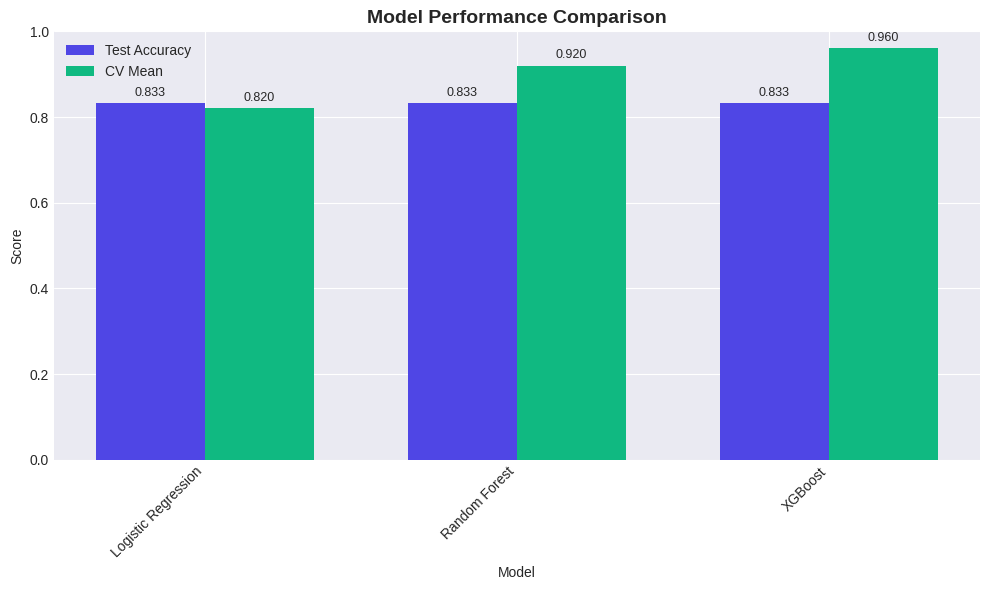

In [ ]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(9, 6))

x = range(len(comparison_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparison_df['Test Accuracy'], width, label='Test Accuracy', color='#4f46e5')
bars2 = ax.bar([i + width/2 for i in x], comparison_df['CV Mean'], width, label='CV Mean', color='#10b981')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

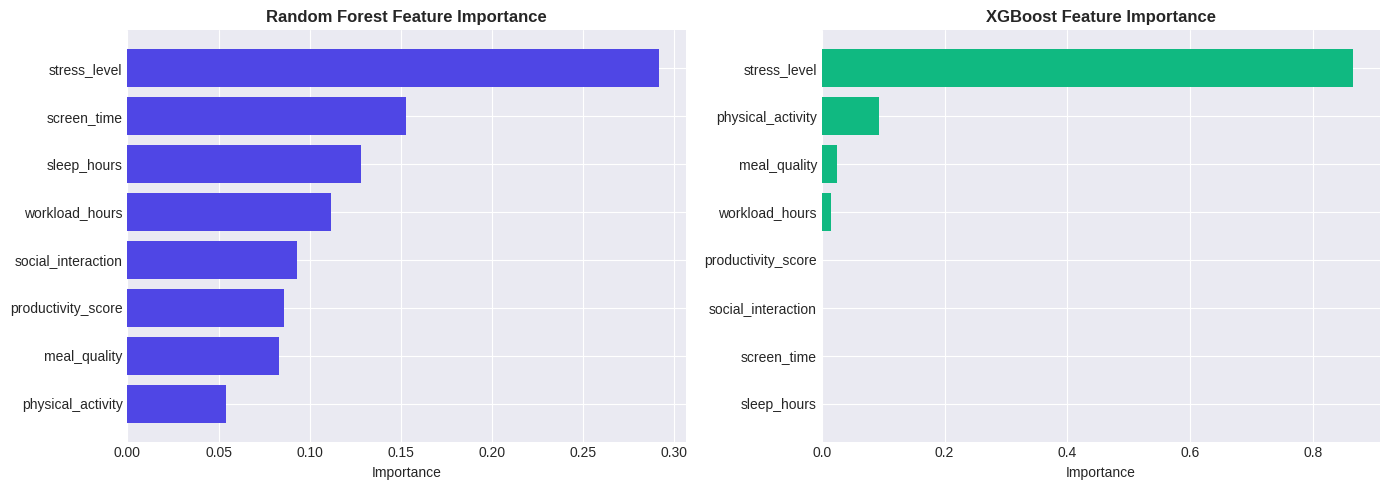


Top 3 features from XGBoost:
  meal_quality: 0.0253
  physical_activity: 0.0932
  stress_level: 0.8659


In [ ]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
rf_imp = pd.DataFrame({'feature': features, 'importance': results['Random Forest']['model'].feature_importances_}).sort_values('importance', ascending=True)
axes[0].barh(rf_imp['feature'], rf_imp['importance'], color='#4f46e5')
axes[0].set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost
xgb_imp = pd.DataFrame({'feature': features, 'importance': results['XGBoost']['model'].feature_importances_}).sort_values('importance', ascending=True)
axes[1].barh(xgb_imp['feature'], xgb_imp['importance'], color='#10b981')
axes[1].set_title('XGBoost Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\nTop 3 features from XGBoost:")
for i, row in xgb_imp.tail(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

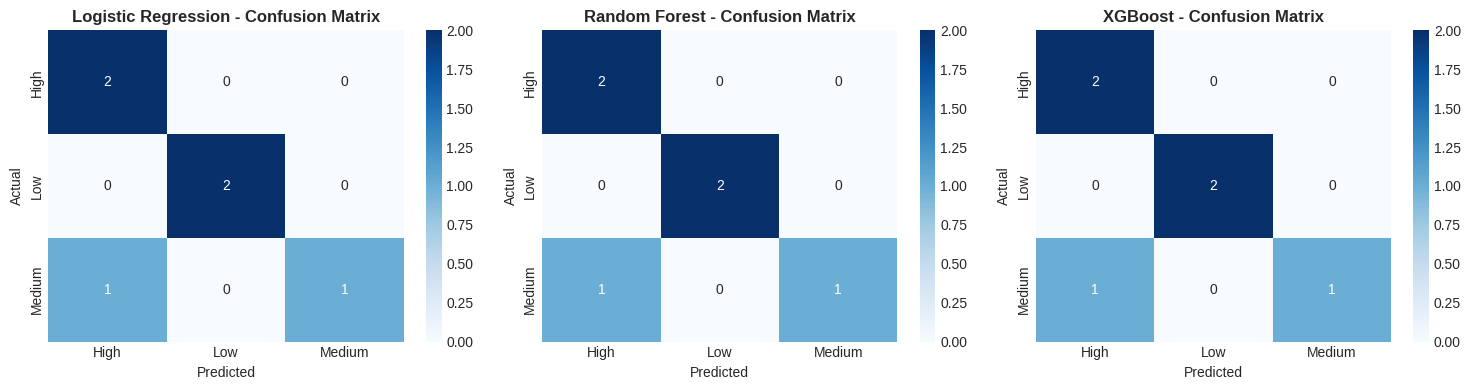

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Summary of findings
print("="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"\n✅ Best performing model: {comparison_df.iloc[0]['Model']}")
print(f"   Test accuracy: {comparison_df.iloc[0]['Test Accuracy']:.4f}")
print(f"   Cross-validation score: {comparison_df.iloc[0]['CV Mean']:.4f}")
print(f"\n✅ Top 3 most important features (XGBoost):")
for i, row in xgb_imp.tail(3).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")
print(f"\n✅ Models saved to: ../models/")
print("✅ Scaler saved to: ../models/scaler.pkl")
print("✅ Label encoder saved to: ../models/label_encoder.pkl")

MODEL TRAINING SUMMARY

✅ Best performing model: Logistic Regression
   Test accuracy: 0.8333
   Cross-validation score: 0.8200

✅ Top 3 most important features (XGBoost):
   7. meal_quality: 0.0253
   5. physical_activity: 0.0932
   3. stress_level: 0.8659

✅ Models saved to: ../models/
✅ Scaler saved to: ../models/scaler.pkl
✅ Label encoder saved to: ../models/label_encoder.pkl
